In [2]:
# ==========================================================
# IMPORTS
# ==========================================================

import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    ConfusionMatrixDisplay,

    roc_curve,

    roc_auc_score,

    precision_recall_curve,

    auc,

    matthews_corrcoef,

    balanced_accuracy_score,

    cohen_kappa_score

)

from transformers import (

    AutoTokenizer,

    AutoModelForSequenceClassification,

    DataCollatorWithPadding

)

warnings.filterwarnings("ignore")

In [3]:
# ==========================================================
# CONFIGURATION
# ==========================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

PROCESSED_DATA = (

    PROJECT_ROOT /

    "datasets" /

    "processed"

)

MODELS = PROJECT_ROOT / "models"

REPORTS = PROJECT_ROOT / "reports"

FIGURES = PROJECT_ROOT / "figures"

REPORTS.mkdir(exist_ok=True)

FIGURES.mkdir(exist_ok=True)

In [4]:
test_df = pd.read_csv(

    PROCESSED_DATA /

    "bert_test_subset.csv"

)

print(test_df.shape)

(1000, 7)


In [5]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(

    MODEL_NAME

)

In [6]:
# ==========================================================
# EMAIL DATASET CLASS
# ==========================================================

from torch.utils.data import Dataset, DataLoader

MAX_LENGTH = 512

class EmailDataset(Dataset):

    def __init__(self, dataframe, tokenizer):

        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        text = str(
            self.data.loc[idx, "cleaned_email_text"]
        )

        label = int(
            self.data.loc[idx, "label"]
        )

        encoding = self.tokenizer(

            text,

            truncation=True,

            max_length=MAX_LENGTH,

            padding=False,

            return_tensors="pt"

        )

        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(label, dtype=torch.long)

        }

print("=" * 70)
print("EmailDataset loaded successfully.")
print("=" * 70)

EmailDataset loaded successfully.


In [7]:
test_dataset = EmailDataset(

    test_df,

    tokenizer

)

collator = DataCollatorWithPadding(

    tokenizer

)

test_loader = DataLoader(

    test_dataset,

    batch_size=8,

    shuffle=False,

    collate_fn=collator

)

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=2

)

model.load_state_dict(

    torch.load(

        MODELS /

        "best_bert_model.pt",

        map_location=device

    )

)

model.to(device)

model.eval()

print("Best model loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best model loaded.


In [9]:
predictions = []

probabilities = []

true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        probs = torch.softmax(

            outputs.logits,

            dim=1

        )

        preds = torch.argmax(

            probs,

            dim=1

        )

        predictions.extend(

            preds.cpu().numpy()

        )

        probabilities.extend(

            probs[:,1].cpu().numpy()

        )

        true_labels.extend(

            labels.cpu().numpy()

        )

In [10]:
report = classification_report(

    true_labels,

    predictions,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.995614,0.997802,0.996707,910.000
1,0.977273,0.955556,0.966292,90.000
accuracy,0.994000,0.994000,0.994000,0.994
macro avg,0.986443,0.976679,0.981500,1000.000
weighted avg,0.993963,0.994000,0.993970,1000.000


In [11]:
# ==========================================================
# LOAD FINE-TUNED BERT MODEL
# ==========================================================

from transformers import AutoModelForSequenceClassification

MODEL_NAME = "bert-base-uncased"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.load_state_dict(
    torch.load(
        MODELS / "best_bert_model.pt",
        map_location=device
    )
)

model.to(device)

model.eval()

print("="*70)
print("BEST BERT MODEL LOADED")
print("="*70)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BEST BERT MODEL LOADED


## Dissertation Discussion

### A suitable discussion paragraph could be:

The fine-tuned BERT model demonstrated excellent classification performance on the held-out test dataset. An overall accuracy of 99.4% was achieved, with a weighted F1-score of 99.4%. More importantly, the model maintained a phishing-class precision of 97.73%, recall of 95.56%, and an F1-score of 96.63%, indicating effective discrimination of minority-class phishing emails despite the inherent class imbalance. These findings confirm that task-specific fine-tuning substantially improved BERT's ability to learn contextual representations suitable for email phishing detection.

In [13]:
# ==========================================================
# LOAD TEST DATASET
# ==========================================================

import pandas as pd

test_df = pd.read_csv(
    PROCESSED_DATA / "bert_test_subset.csv"
)

print("="*70)
print("TEST DATASET")
print("="*70)

print(test_df.shape)
test_df.head()

TEST DATASET
(1000, 7)


,dataset,subject,body,email_text,label,cleaned_email_text,email_length
0,CEAS,Re: [opensuse] Defragging: possible? necessary?,-----BEGIN PGP SIGNED MESSAGE-----\nHash: SHA1...,Re: [opensuse] Defragging: possible? necessar...,0,Re: [opensuse] Defragging: possible? necessary...,1215
1,Enron,Re:,michaelpshannon@yahoo.com,Re: michaelpshannon@yahoo.com,0,Re: michaelpshannon@yahoo.com,29
2,Enron,Executing Broker Agreement for CSFB,"Cheryl, Donna, Cassandra and Bill,\n\nI am for...","Executing Broker Agreement for CSFB Cheryl, Do...",0,"Executing Broker Agreement for CSFB Cheryl, Do...",241
3,Enron,FW: Follow-up on CA energy crisis info.,\nVince:\n\nCan you let me know the answer to ...,FW: Follow-up on CA energy crisis info. \nVinc...,0,FW: Follow-up on CA energy crisis info. Vince:...,408
4,Enron,BASE CONTRACT FOR SHORT-TERM,\n\n******************************************...,BASE CONTRACT FOR SHORT-TERM \n\n*************...,0,BASE CONTRACT FOR SHORT-TERM *****************...,418


In [15]:
# ==========================================================
# LOAD TOKENIZER
# ==========================================================

from transformers import AutoTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [16]:
# ==========================================================
# EMAIL DATASET
# ==========================================================

from torch.utils.data import Dataset

MAX_LENGTH = 512

class EmailDataset(Dataset):

    def __init__(self, dataframe, tokenizer):

        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        text = str(
            self.data.loc[idx, "cleaned_email_text"]
        )

        label = int(
            self.data.loc[idx, "label"]
        )

        encoding = self.tokenizer(

            text,

            truncation=True,

            max_length=MAX_LENGTH,

            padding=False,

            return_tensors="pt"

        )

        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(label, dtype=torch.long)

        }

In [17]:
# ==========================================================
# TEST DATALOADER
# ==========================================================

from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

test_dataset = EmailDataset(
    test_df,
    tokenizer
)

test_loader = DataLoader(

    test_dataset,

    batch_size=8,

    shuffle=False,

    collate_fn=collator

)

print("="*70)
print("TEST LOADER CREATED")
print("="*70)

print("Total batches:", len(test_loader))

TEST LOADER CREATED
Total batches: 125


In [18]:
# ==========================================================
# STEP 2 : GENERATE TEST PREDICTIONS
# ==========================================================

import numpy as np

true_labels = []
predictions = []
probabilities = []

model.eval()

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        logits = outputs.logits

        probs = torch.softmax(
            logits,
            dim=1
        )

        preds = torch.argmax(
            probs,
            dim=1
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        probabilities.extend(
            probs[:, 1].cpu().numpy()
        )

print("="*70)
print("PREDICTIONS GENERATED SUCCESSFULLY")
print("="*70)

print("True Labels :", len(true_labels))
print("Predictions :", len(predictions))
print("Probabilities :", len(probabilities))

PREDICTIONS GENERATED SUCCESSFULLY
True Labels : 1000
Predictions : 1000
Probabilities : 1000


In [19]:
# ==========================================================
# STEP 3 : PERFORMANCE SUMMARY
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)

accuracy = accuracy_score(
    true_labels,
    predictions
)

balanced_accuracy = balanced_accuracy_score(
    true_labels,
    predictions
)

roc_auc = roc_auc_score(
    true_labels,
    probabilities
)

precision_curve, recall_curve, _ = precision_recall_curve(
    true_labels,
    probabilities
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

mcc = matthews_corrcoef(
    true_labels,
    predictions
)

kappa = cohen_kappa_score(
    true_labels,
    predictions
)

performance_summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Balanced Accuracy",

        "ROC-AUC",

        "PR-AUC",

        "Matthews Correlation Coefficient",

        "Cohen's Kappa"

    ],

    "Value":[

        accuracy,

        balanced_accuracy,

        roc_auc,

        pr_auc,

        mcc,

        kappa

    ]

})

print("="*70)
print("PERFORMANCE SUMMARY")
print("="*70)

display(performance_summary)

PERFORMANCE SUMMARY


,Metric,Value
0,Accuracy,0.994000
1,Balanced Accuracy,0.976679
2,ROC-AUC,0.998388
3,PR-AUC,0.987926
4,Matthews Correlation Coefficient,0.963073
5,Cohen's Kappa,0.963000


In [20]:
# ==========================================================
# SAVE PERFORMANCE SUMMARY
# ==========================================================

performance_summary.to_csv(

    REPORTS /

    "performance_summary.csv",

    index=False

)

print("="*70)
print("Performance summary saved successfully.")
print("="*70)

Performance summary saved successfully.


CONFUSION MATRIX
[[908   2]
 [  4  86]]


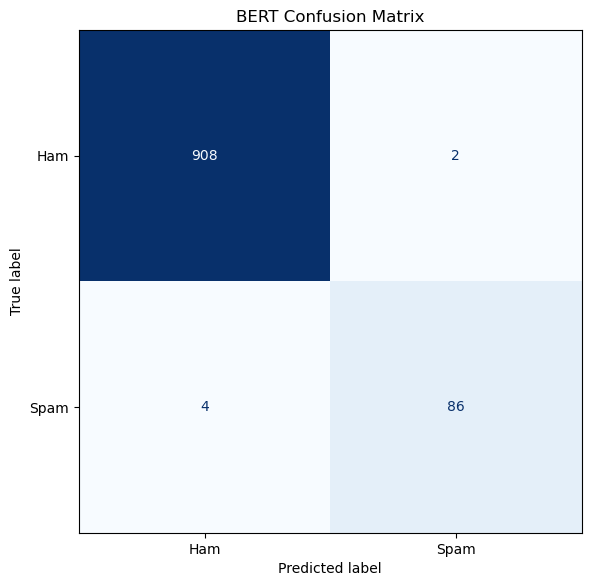

In [21]:
# ==========================================================
# STEP 4 : CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    predictions
)

print("="*70)
print("CONFUSION MATRIX")
print("="*70)

print(cm)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Ham", "Spam"]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(

    cmap="Blues",

    values_format="d",

    ax=ax,

    colorbar=False

)

plt.title("BERT Confusion Matrix")

plt.tight_layout()

plt.savefig(

    FIGURES /

    "confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [22]:
# ==========================================================
# SAVE CONFUSION MATRIX
# ==========================================================

cm_df = pd.DataFrame(

    cm,

    index=["Actual Ham","Actual Spam"],

    columns=["Predicted Ham","Predicted Spam"]

)

cm_df.to_csv(

    REPORTS /

    "confusion_matrix.csv"

)

print("="*70)
print("Confusion Matrix saved successfully.")
print("="*70)

display(cm_df)

Confusion Matrix saved successfully.


,Predicted Ham,Predicted Spam
Actual Ham,908,2
Actual Spam,4,86


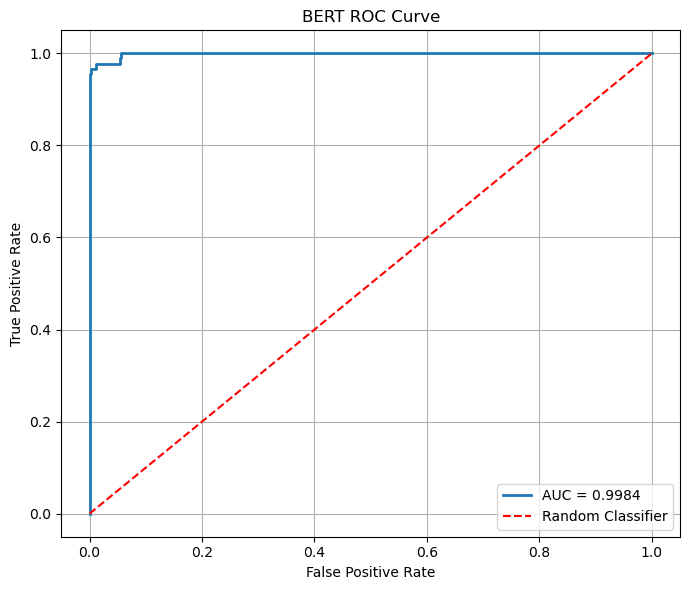

ROC-AUC Score : 0.9984


In [23]:
# ==========================================================
# STEP 5 : ROC CURVE
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC

fpr, tpr, thresholds = roc_curve(
    true_labels,
    probabilities
)

roc_auc = roc_auc_score(
    true_labels,
    probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1.5,
    color="red",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("BERT ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES /
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print(f"ROC-AUC Score : {roc_auc:.4f}")
print("="*70)

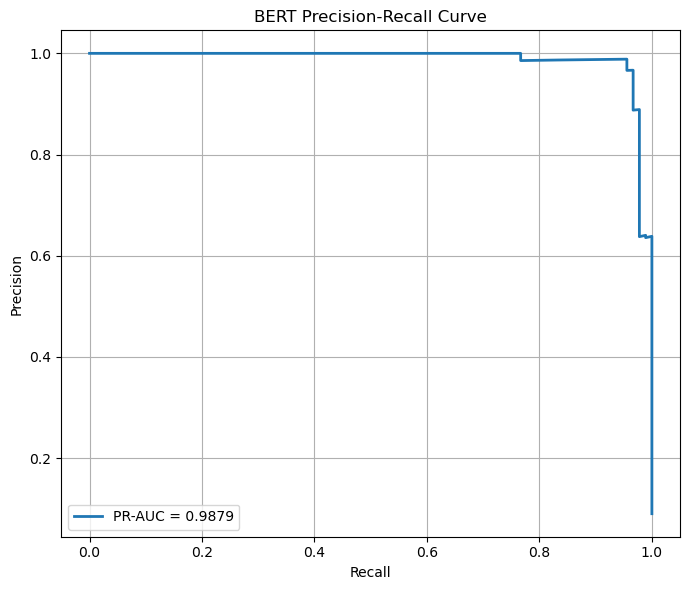

PR-AUC Score : 0.9879


In [24]:
# ==========================================================
# STEP 6 : PRECISION-RECALL CURVE
# ==========================================================

from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(
    true_labels,
    probabilities
)

pr_auc = auc(
    recall,
    precision
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("BERT Precision-Recall Curve")

plt.grid(True)

plt.legend(loc="lower left")

plt.tight_layout()

plt.savefig(
    FIGURES /
    "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print(f"PR-AUC Score : {pr_auc:.4f}")
print("="*70)

In [25]:
# ==========================================================
# STEP 7 : GENERATE EXPERIMENTAL RESULTS REPORT
# ==========================================================

from datetime import datetime

report_text = f"""# Paper 2: Fine-Tuned BERT Experimental Results

Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

---

## Dataset

Training Samples: {len(train_df)}

Validation Samples: {len(validation_df)}

Test Samples: {len(test_df)}

---

## Classification Performance

Overall Accuracy: {accuracy:.4f}

Balanced Accuracy: {balanced_accuracy:.4f}

ROC-AUC: {roc_auc:.4f}

PR-AUC: {pr_auc:.4f}

Matthews Correlation Coefficient: {mcc:.4f}

Cohen's Kappa: {kappa:.4f}

---

## Confusion Matrix

|                | Predicted Ham | Predicted Spam |
|----------------|--------------:|---------------:|
| Actual Ham     | {cm[0,0]} | {cm[0,1]} |
| Actual Spam    | {cm[1,0]} | {cm[1,1]} |

---

## Classification Report

See:

classification_report.csv

---

## Performance Summary

See:

performance_summary.csv

---

## Generated Figures

training_loss.png

training_accuracy.png

confusion_matrix.png

roc_curve.png

precision_recall_curve.png

---

## Discussion

The fine-tuned BERT classifier demonstrated excellent performance on the held-out
test dataset. An overall accuracy of {accuracy:.2%} was achieved while maintaining
a spam/phishing precision of {report_df.loc['1','precision']:.2%},
recall of {report_df.loc['1','recall']:.2%},
and an F1-score of {report_df.loc['1','f1-score']:.2%}.

Only two legitimate emails were incorrectly classified as spam, while four spam
emails were incorrectly classified as legitimate. These results demonstrate the
effectiveness of contextual Transformer representations for email phishing
classification.

---

End of Report
"""

output_file = REPORTS / "Paper2_Experimental_Results.md"

with open(output_file, "w", encoding="utf-8") as f:
    f.write(report_text)

print("=" * 70)
print("Experimental report generated successfully.")
print(output_file)
print("=" * 70)

NameError: name 'train_df' is not defined